#  Entropy aggregation calibration
### (Fixed weight in aggregation of attn and final token entropy)

In [23]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from typing import Optional

sys.path.append("../../../services/")
from index import Index, IndexDataset
from process_funcs import retrieve_answer_token_index
from metric_funcs import (
    calculate_ece_adaptive_bins, 
    calculate_norm_entropy, 
    calculate_roc_auc
)

## Environment preparation

In [24]:
LAYERS_COUNT = 28
HEADS_COUNT = 28 
HPARAMETER_SEARCH_TRIALS = 15
BEST_HEADS_GROUP_SIZE = 5

torch.random.manual_seed(42)

In [25]:
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"Index {i}: {props.name}, UUID: {props.uuid}")

Index 0: NVIDIA L40, UUID: 441e6008-cd27-34b5-c81a-17dad9d4a894
Index 1: NVIDIA L40S, UUID: c15d4e7a-29b2-896a-f7bf-3d1a528040a5
Index 2: NVIDIA L40, UUID: 31a471eb-a3b0-032b-8b74-9bd805c42af3
Index 3: NVIDIA L40, UUID: 7b7e27a5-a434-d736-eabd-b9414645af76
Index 4: NVIDIA L40S, UUID: d5913034-d8e8-b46e-940e-7df6d85d3884
Index 5: NVIDIA H100 NVL, UUID: d4d3fa02-fdea-80f5-9082-0157b1423027
Index 6: NVIDIA H100 PCIe, UUID: 1ea36751-5cc4-4522-aa5e-55350c485c0c


In [26]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)

cuda:3


## Core functions

In [27]:
# Funtion that calculates confidence of LLM's answers 
# based on aggregation of attention and final answer token distributions entropies

def calculate_llm_confidence(attn_confidence: torch.Tensor, final_token_confidence: torch.Tensor, gamma=0.7):
    aggregated_confidence = gamma * attn_confidence + (1 - gamma) * final_token_confidence
    return aggregated_confidence

In [28]:
# Module which will learn parameters for llm beta calibration

class BetaCalibration(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.log_a = nn.Parameter(torch.tensor(0.0, device=device))
        self.log_b = nn.Parameter(torch.tensor(0.0, device=device))
        self.c = nn.Parameter(torch.tensor(0.0, device=device))
        self.eps = 1e-8

    def forward(self, probs):
        probs = torch.clamp(probs, self.eps, 1 - self.eps)

        a = torch.exp(self.log_a)
        b = torch.exp(self.log_b)
        calibrated_probs = torch.sigmoid(
            self.c + a * torch.log(probs) - b * torch.log(1 - probs)
        )
        return calibrated_probs

    def calibrate(self, probs):
        self.eval()
        with torch.no_grad():
            return self.forward(probs).cpu()

In [29]:
# Function to find indices of best layer and head based on TOHA article

def find_best_layer_head_hal_dif_power(train_data):
    hallu_elem_ids = torch.argwhere(train_data["labels"] == False)
    truth_elem_ids = torch.argwhere(train_data["labels"] == True)

    hal_dif_power_results = torch.stack(
        [
            train_data[f"attn_entropy{l}_{h}"][hallu_elem_ids].mean() - train_data[f"attn_entropy{l}_{h}"][truth_elem_ids].mean()
            for l in range(LAYERS_COUNT)
                for h in range(HEADS_COUNT)
        ]
    )
    
    hal_dif_power_matrix = hal_dif_power_results.reshape(LAYERS_COUNT, HEADS_COUNT).cpu()

    plt.figure(figsize=(5, 4))

    sns.heatmap(hal_dif_power_matrix, annot=False, cmap="Reds")
    plt.title("Hallucination difference power values by Layer and Head")
    plt.xlabel("Head ID")
    plt.ylabel("Layer ID")
    plt.gca().invert_yaxis()
    plt.show()
    
    best_score_idx = torch.argsort(hal_dif_power_results, descending=True)[:BEST_HEADS_GROUP_SIZE]
    print(f"Best metric value: {torch.max(hal_dif_power_results).item()}")
    
    return best_score_idx // LAYERS_COUNT, best_score_idx % HEADS_COUNT

In [30]:
# Function to find indices of best layer and head based on ROC AUC

def find_best_layer_head_roc_auc(train_data):
    roc_auc_results = torch.stack(
        [
            torch.tensor(calculate_roc_auc(
                train_data[f"attn_entropy{l}_{h}"], 
                1 - train_data[f"labels"]
            ))
            for l in range(LAYERS_COUNT)
                for h in range(HEADS_COUNT)
        ]
    )

    roc_auc_matrix = roc_auc_results.reshape(LAYERS_COUNT, HEADS_COUNT).cpu()

    plt.figure(figsize=(5, 4))

    sns.heatmap(roc_auc_matrix, annot=False, cmap="Reds")
    plt.title("ROC AUC values by Layer and Head")
    plt.xlabel("Head ID")
    plt.ylabel("Layer ID")
    plt.gca().invert_yaxis()
    plt.show()
    
    best_score_idx = torch.argsort(roc_auc_results, descending=True)[:BEST_HEADS_GROUP_SIZE]
    print(f"Best metric value: {torch.max(roc_auc_results).item()}")
    
    return best_score_idx // LAYERS_COUNT, best_score_idx % HEADS_COUNT

In [31]:
# Function to fit the calibration model

def fit_calibration_model(
    model: nn.Module,
    train_data: IndexDataset,
    test_data: Optional[IndexDataset] = None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=64,
    epochs=3,
    plot_interval=3,
    verbose=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs * (len(train_data) / batch_size), lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in range(epochs):
        for start in range(0, len(train_data) - batch_size, batch_size):
            train_batch = train_data.get(start, start + batch_size)
            if not train_batch:
                continue

            optimizer.zero_grad()
            
            train_batch_confidence = train_batch["confidence"].to(device=device, dtype=torch.float32)
            train_batch_labels = train_batch["labels"].to(device=device, dtype=torch.float32)
            
            train_cal_scores = model(train_batch_confidence)

            train_loss = torch.nn.functional.binary_cross_entropy(
                train_cal_scores,
                train_batch_labels
            )

            train_loss.backward()
            # torch.nn.utils.clip_grad_norm_(temp_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_batch_confidence = test_batch["confidence"].to(device=device, dtype=torch.float32)
                    test_batch_labels = test_batch["labels"].to(device=device, dtype=torch.float32)
                    
                    with torch.no_grad():
                        test_cal_scores = model(test_batch_confidence)
                        test_loss = torch.nn.functional.binary_cross_entropy(
                            test_cal_scores,
                            test_batch_labels
                        )
                        test_losses.append(test_loss.item())
                    
                    iterations.append(iteration_counter)
            iteration_counter += 1

    if len(iterations) > 0 and verbose:
        plt.figure(figsize=(4, 4))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model

In [32]:
# Function to find the best hyperparameters for calibration model

def fit_hparameters(
    train_data: IndexDataset,
    test_data: IndexDataset,
    verbose=False
    ):
    results = []
    for _ in tqdm(range(HPARAMETER_SEARCH_TRIALS)):
        lr_max = np.random.choice([1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
        lr_min = np.random.choice([1e-3, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6])
        batch_size = 16
        epochs = np.random.choice([3, 5, 10])

        model = fit_calibration_model(
            BetaCalibration(),
            train_data=train_data,
            test_data=test_data,
            lr_max=lr_max,
            lr_min=lr_min,
            batch_size=batch_size,
            epochs=epochs,
            verbose=verbose
        )
        
        val_calibrated_probs = model.calibrate(test_data.get()["confidence"])    
        ece = calculate_ece_adaptive_bins(
            val_calibrated_probs,
            test_data.get()["labels"],
            verbose=verbose,
            device=device 
        )
        
        print(f"Current ECE: {ece}")
        results.append(
            {
                "hparameters": {
                    "lr_max": lr_max,
                    "lr_min": lr_min,
                    "batch_size": batch_size,
                    "epochs": epochs,
                },
                "parameters": model.state_dict(),
                "ece": ece,
            }
        )

    return min(results, key=lambda x: x["ece"])

In [33]:
# Function to test calibration model

def test_calibration_model(
    model: nn.Module,
    X_test: torch.Tensor,
    y_test: torch.Tensor
):
    not_calibrated_test_answers_probs = X_test
    calibrated_test_answers_probs = model.calibrate(
        X_test
    )
    
    print(
        f"ECE on NON calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            not_calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )

    print(
        f"ECE on calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )
    
    accuracies = (
        y_test
    ).to(torch.float)
    print(f"Accuracy on answer from test: {torch.mean(accuracies).item()}")

## Index preparation 

In [34]:
index = Index("../../../index_data/mistral0.3_MMLU-PRO_attn_cropped_12000")

In [35]:
# Function to process data for training phase

def create_process_elements_main(best_layers, best_heads):
    def process_elements_main(index_data: np.array):
        processed = {}

        # Getting labels of if the answer is correct or not 
        labels = torch.zeros(len(index_data), device=device, dtype=torch.long)
        for i, elem in enumerate(index_data):
            answer_token_index = retrieve_answer_token_index(elem["score_data"])
            labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
        processed["labels"] = labels
                
        # Getting normilized attn entropy scores for the answer token distribution 
        # for each best layer and head pair 
        agg_norm_attn_entropy = torch.stack([
                torch.stack([
                    x["norm_attention_entropy"][0][l][h] 
                    for l, h in zip(best_layers, best_heads)
                ])
                for x in index_data
            ]).squeeze(-1).mean(-1).to(dtype=torch.float32, device=device)
            
        # Getting probability scores of the answer token 
        # from the last layer of the LLM
        final_token_scores = torch.stack(
            [
                x
                ["score_data"]
                [retrieve_answer_token_index(x["score_data"])]
                ["top_probs"] 
                for x in index_data
            ]
        ).clamp(1e-8).to(dtype=torch.float32, device=device)
        
        attn_confidence = 1 - agg_norm_attn_entropy    
        final_token_confidence = 1 - calculate_norm_entropy(final_token_scores)
        processed["confidence"] = calculate_llm_confidence(attn_confidence, final_token_confidence)
            
        return processed
    return process_elements_main

In [36]:
# Function to process data for head selection phase

def process_elements_hal(index_data: np.array):
    processed = {}
    
    # Getting labels of if the answer is correct or not 
    labels = torch.zeros(len(index_data), device=device, dtype=torch.long)
    for i, elem in enumerate(index_data):
        answer_token_index = retrieve_answer_token_index(elem["score_data"])
        labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
    processed["labels"] = labels

    for l in tqdm(range(LAYERS_COUNT)):
        for h in range(HEADS_COUNT):
            processed[f"attn_entropy{l}_{h}"] = torch.stack(
                [x["attention_entropy"][0][l][h] for x in index_data]
            ).squeeze(-1).to(dtype=torch.float32, device=device)
            
            processed[f"norm_attn_entropy{l}_{h}"] = torch.stack(
                [x["norm_attention_entropy"][0][l][h] for x in index_data]
            ).squeeze(-1).to(dtype=torch.float32, device=device)
        
    return processed

## Head selection

In [37]:
head_selection_dataset = IndexDataset(
    index, process_elements_hal, split="val", load_all_data=True
)

100%|██████████| 28/28 [00:05<00:00,  5.12it/s]


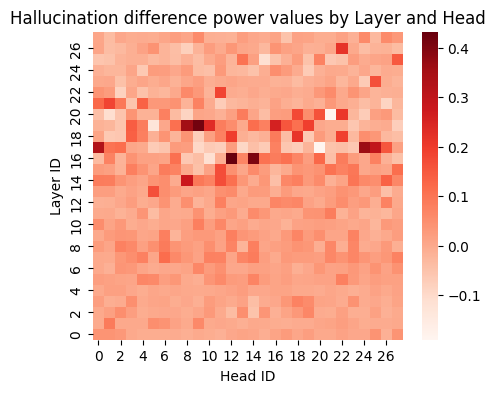

Best metric value: 0.432204008102417
Best Layers and Heads: [(16, 12), (19, 9), (16, 14), (17, 24), (19, 8)]


In [38]:
hal_dif_best_layers, hal_dif_best_heads = find_best_layer_head_hal_dif_power(head_selection_dataset.get())
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(hal_dif_best_layers, hal_dif_best_heads)]}")

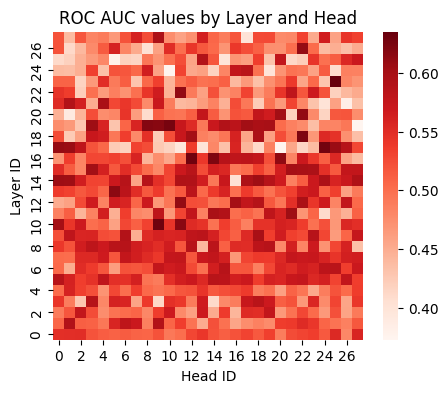

Best metric value: 0.6353250741958618
Best Layers and Heads: [(23, 25), (10, 9), (16, 12), (17, 24), (19, 10)]


In [39]:
roc_auc_best_layers, roc_auc_best_heads = find_best_layer_head_roc_auc(head_selection_dataset.get())
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(roc_auc_best_layers, roc_auc_best_heads)]}")

## Calibration based on entropy aggregation: 
* TOHA based attn head selection
* Confidence - aggregated entropy from best head and final layer scores
* Calibration layer - Beta calibration 

### Data preparing 

In [40]:
train = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="train", load_all_data=True
)
val = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="val", load_all_data=True
)
test = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="test", load_all_data=True
)

AssertionError: prob_scores must be in (0, 1] range, but: min=nan, max=nan, shape=torch.Size([9599, 10]), negative values: 0, >1 values: 0

### Training model and finding best hparameters

  0%|          | 0/15 [00:00<?, ?it/s]

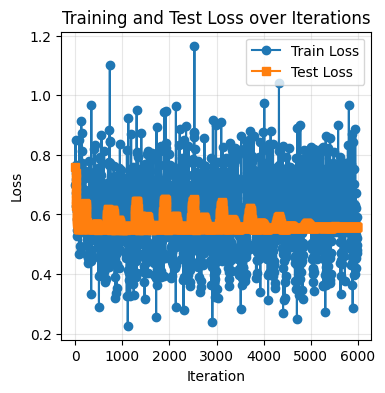

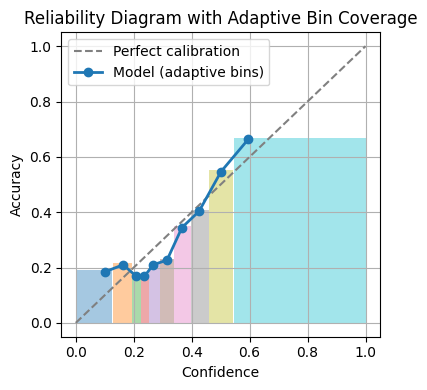

  7%|▋         | 1/15 [00:07<01:40,  7.15s/it]

Current ECE: 0.05441608279943466


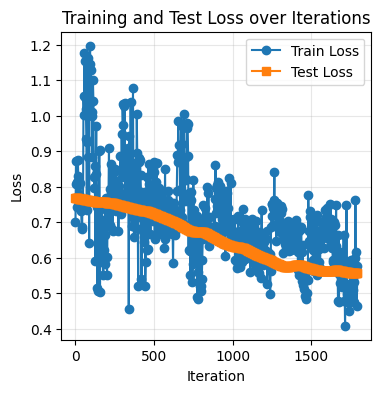

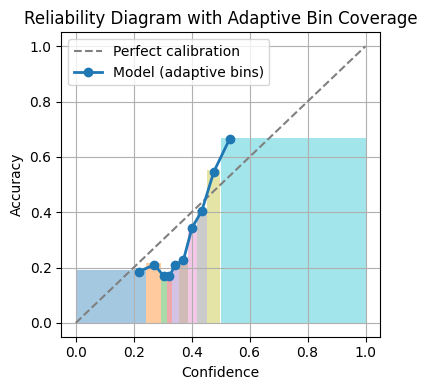

 13%|█▎        | 2/15 [00:09<00:53,  4.09s/it]

Current ECE: 0.09560105949640274


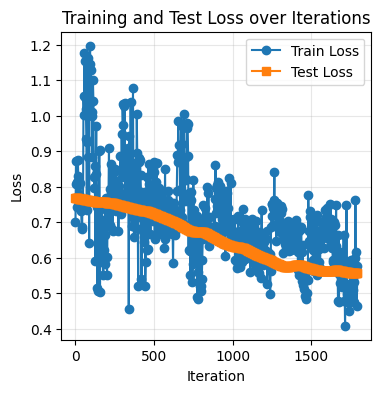

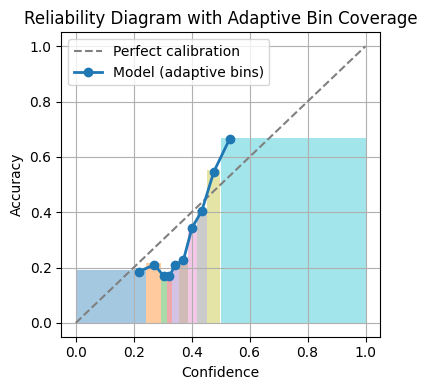

 20%|██        | 3/15 [00:11<00:38,  3.19s/it]

Current ECE: 0.09560105949640274


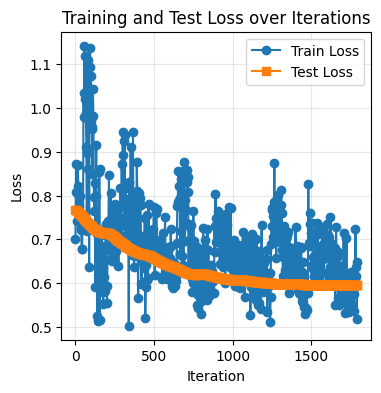

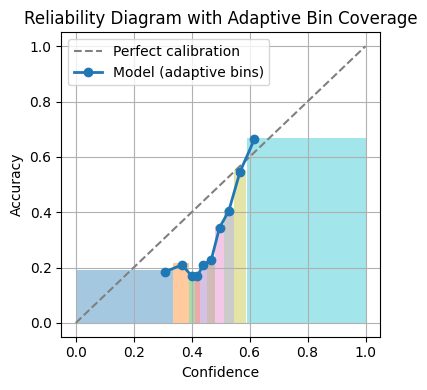

 27%|██▋       | 4/15 [00:13<00:29,  2.72s/it]

Current ECE: 0.15710926055908203


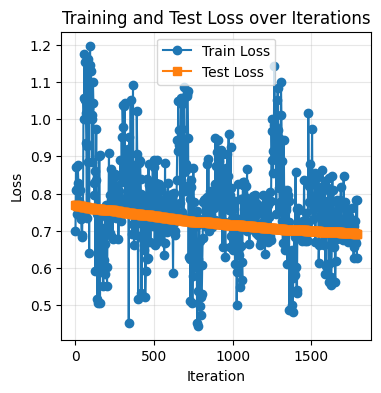

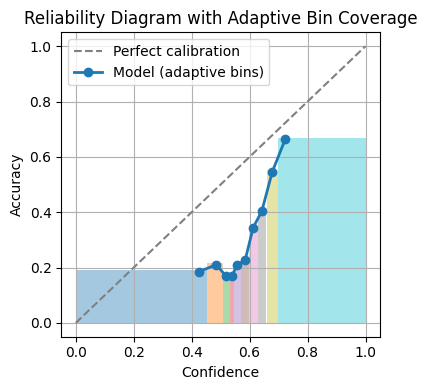

 33%|███▎      | 5/15 [00:15<00:23,  2.39s/it]

Current ECE: 0.2622682750225067


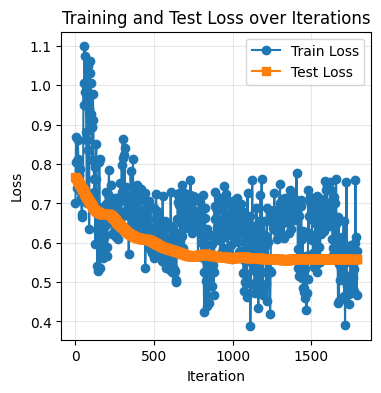

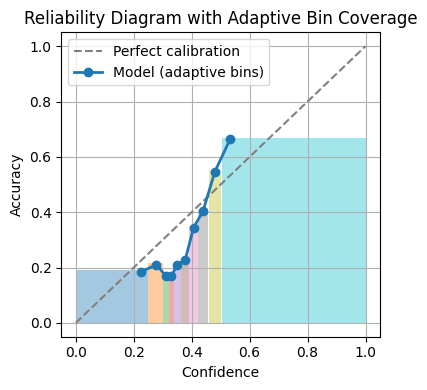

 40%|████      | 6/15 [00:16<00:19,  2.16s/it]

Current ECE: 0.10023432970046997


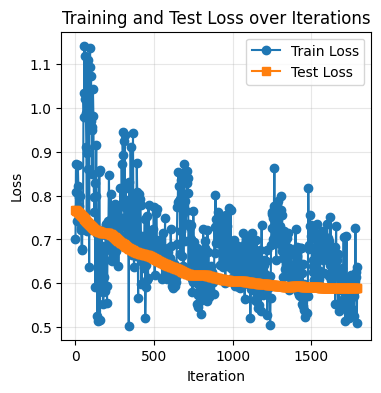

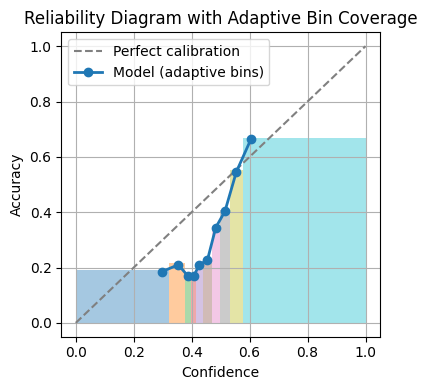

 47%|████▋     | 7/15 [00:18<00:17,  2.17s/it]

Current ECE: 0.1469116508960724


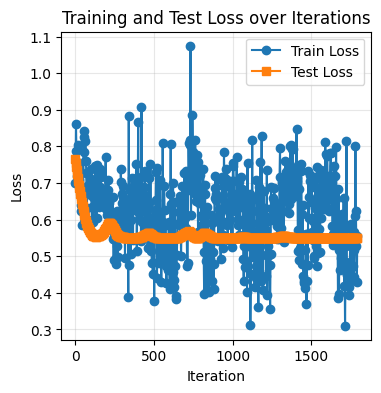

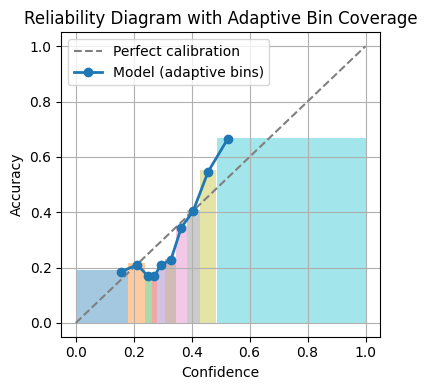

 53%|█████▎    | 8/15 [00:21<00:15,  2.27s/it]

Current ECE: 0.06574603915214539


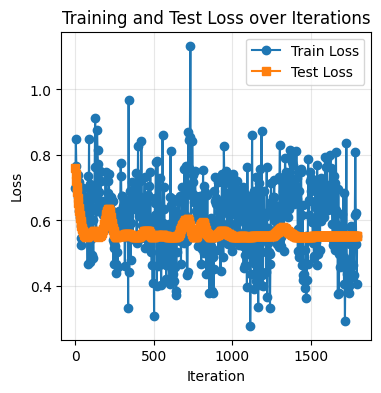

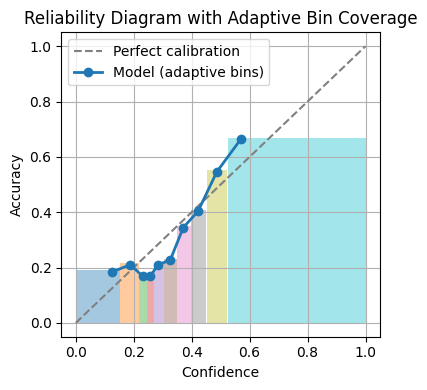

 60%|██████    | 9/15 [00:23<00:13,  2.21s/it]

Current ECE: 0.06064275652170181


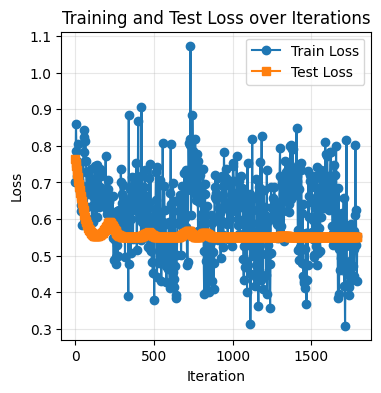

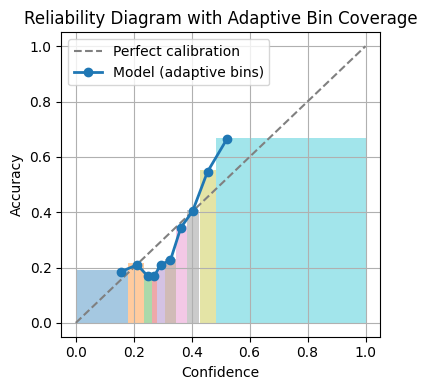

 67%|██████▋   | 10/15 [00:25<00:10,  2.08s/it]

Current ECE: 0.06555283814668655


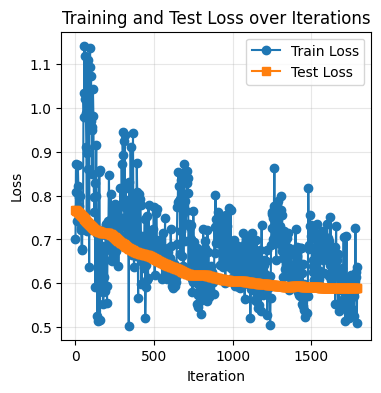

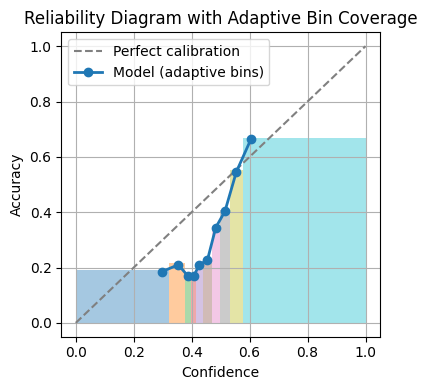

 73%|███████▎  | 11/15 [00:26<00:07,  1.96s/it]

Current ECE: 0.1469116508960724


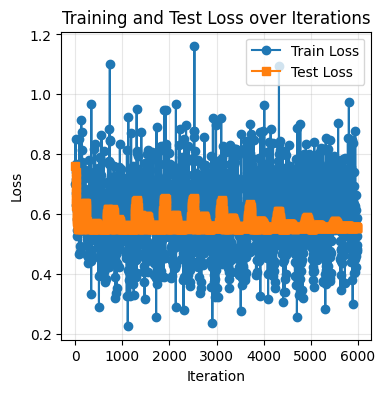

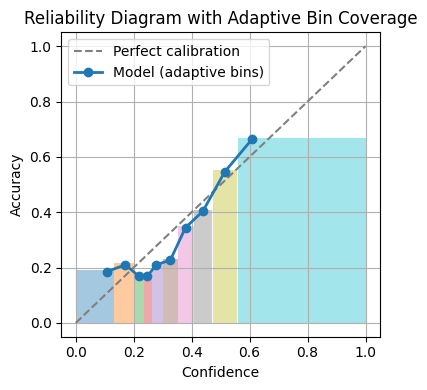

 80%|████████  | 12/15 [00:32<00:08,  2.93s/it]

Current ECE: 0.057015322148799896


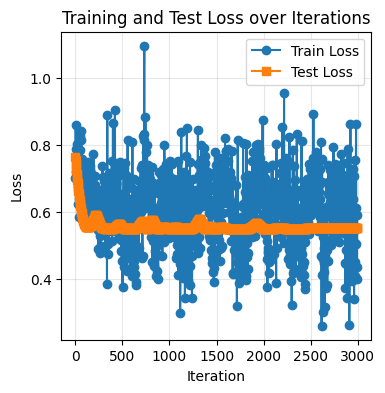

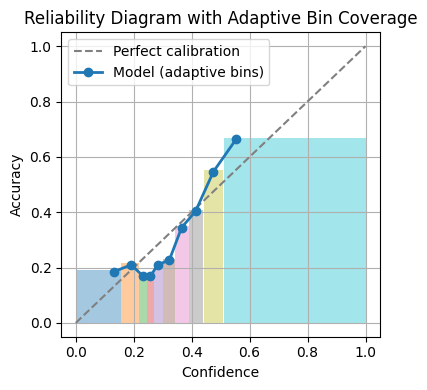

 87%|████████▋ | 13/15 [00:34<00:05,  2.84s/it]

Current ECE: 0.061141304671764374


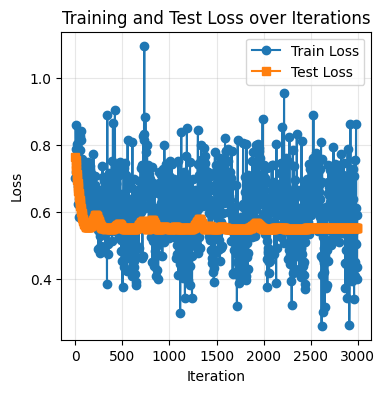

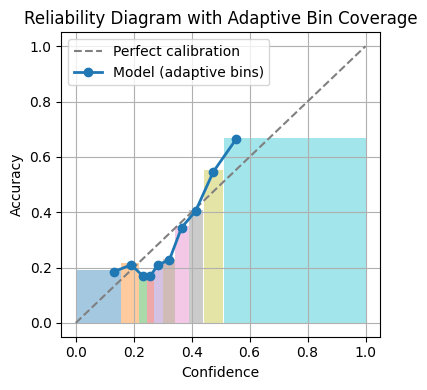

 93%|█████████▎| 14/15 [00:37<00:02,  2.78s/it]

Current ECE: 0.061137501150369644


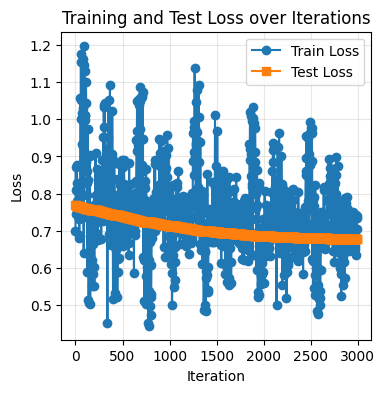

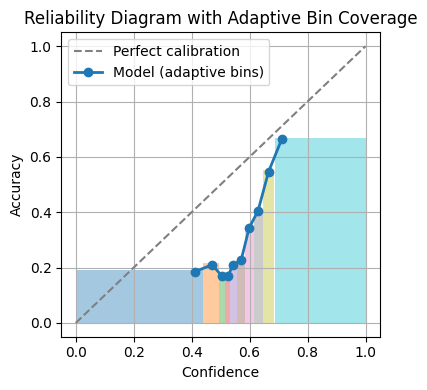

100%|██████████| 15/15 [00:40<00:00,  2.70s/it]

Current ECE: 0.24872910976409912


In [ ]:
fit_results = fit_hparameters(
    train_data=train,
    test_data=val,
    verbose=True
)

### Testing model

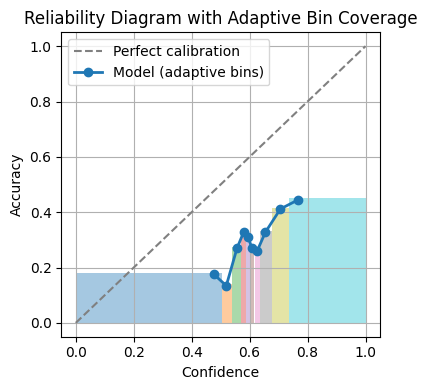

ECE on NON calibrated answer (test data): 0.31567880511283875


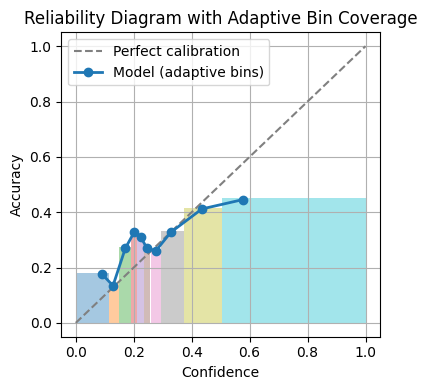

ECE on calibrated answer (test data): 0.060180798172950745
Accuracy on answer from test: 0.2944120168685913


In [ ]:
model = BetaCalibration()
model.load_state_dict(fit_results["parameters"])
model.eval()
    
test_calibration_model(
    model,
    test.get()["confidence"],
    test.get()["labels"],
)

## Calibration based on entropy aggregation: 
* ROC AUC based attn head selection
* Confidence - aggregated entropy from best head and final layer scores
* Calibration layer - Beta calibration 

### Head selection

### Data preparing 

In [ ]:
train = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="train", load_all_data=True
)
val = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="val", load_all_data=True
)
test = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="test", load_all_data=True
)

### Finding best layer and head

### Training model and finding best hparameters

  0%|          | 0/15 [00:00<?, ?it/s]

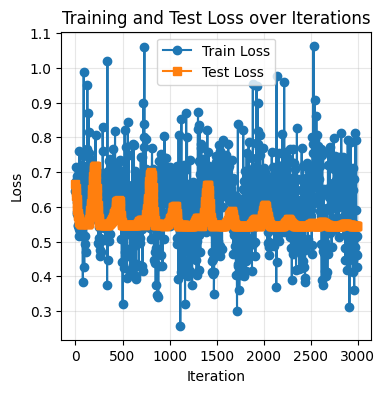

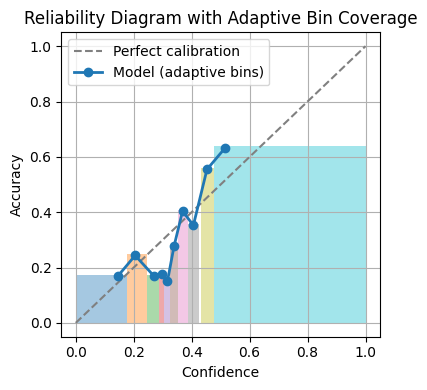

  7%|▋         | 1/15 [00:02<00:37,  2.66s/it]

Current ECE: 0.08232831209897995


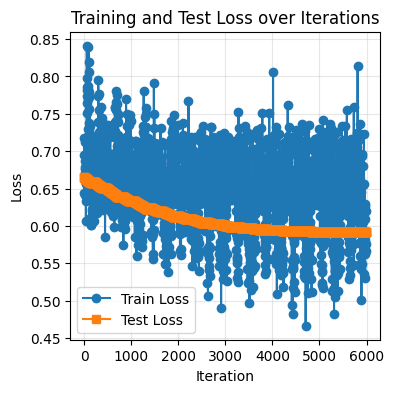

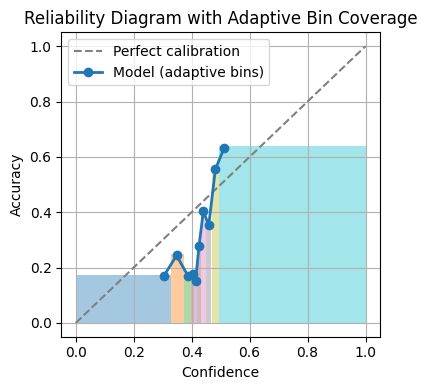

 13%|█▎        | 2/15 [00:08<00:58,  4.48s/it]

Current ECE: 0.14312274754047394


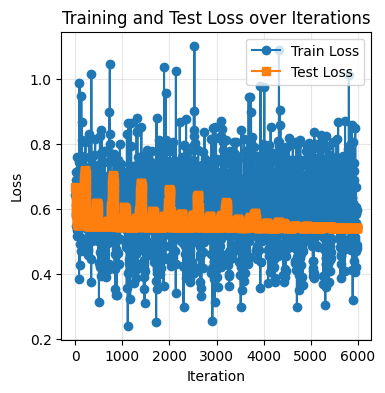

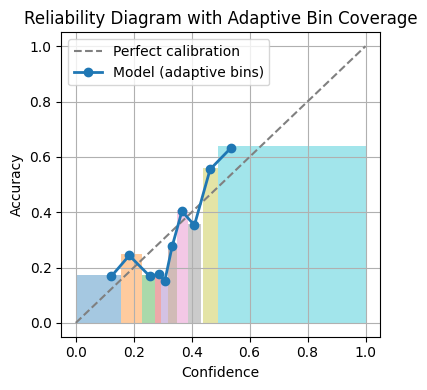

 20%|██        | 3/15 [00:13<00:57,  4.79s/it]

Current ECE: 0.07966649532318115


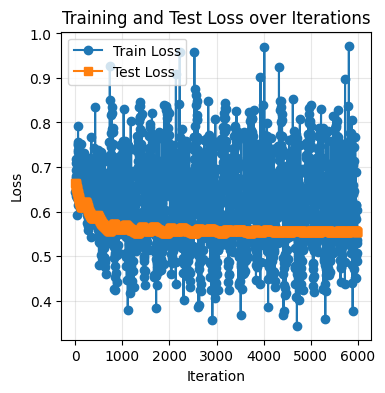

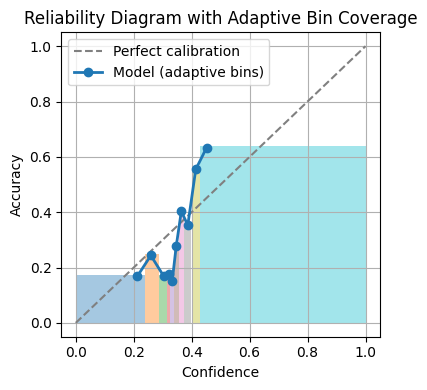

 27%|██▋       | 4/15 [00:19<00:57,  5.27s/it]

Current ECE: 0.0992107093334198


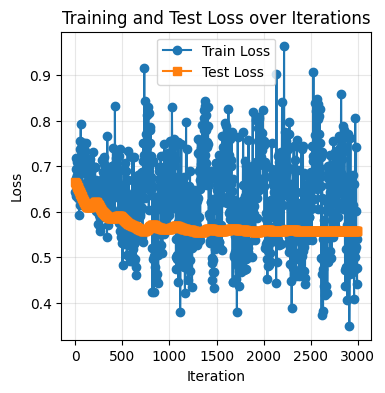

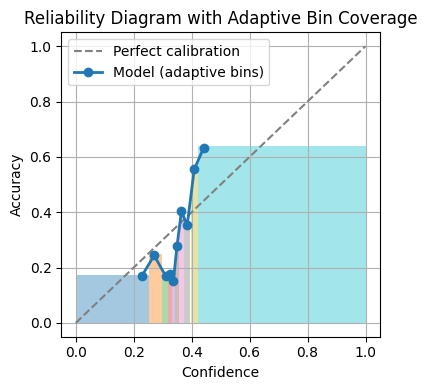

 33%|███▎      | 5/15 [00:23<00:46,  4.69s/it]

Current ECE: 0.10502764582633972


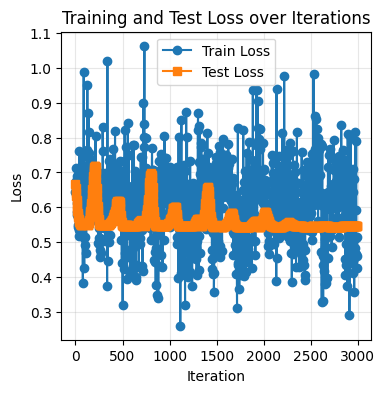

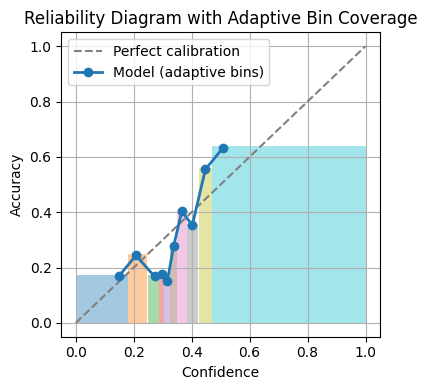

 40%|████      | 6/15 [00:26<00:38,  4.28s/it]

Current ECE: 0.0828145444393158


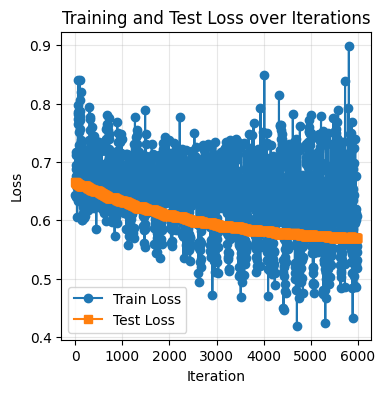

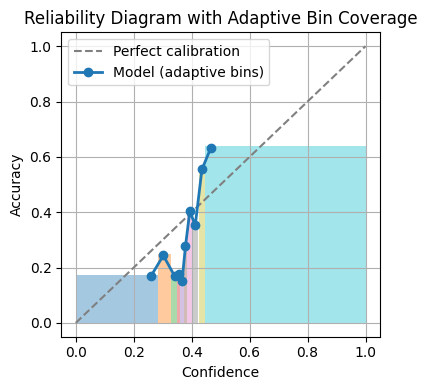

 47%|████▋     | 7/15 [00:33<00:41,  5.20s/it]

Current ECE: 0.11788371950387955


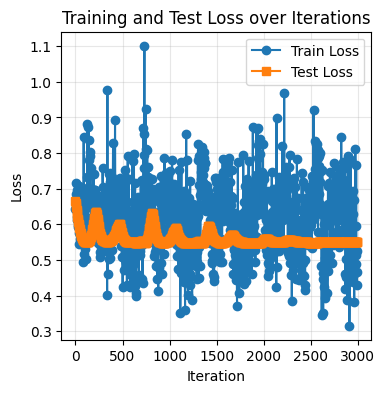

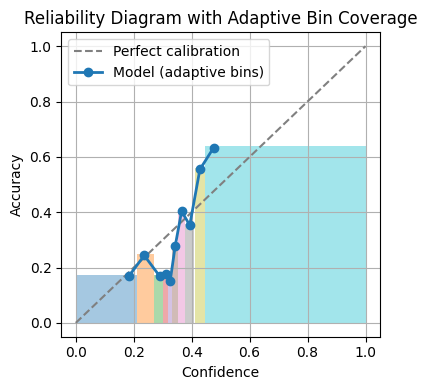

 53%|█████▎    | 8/15 [00:37<00:32,  4.62s/it]

Current ECE: 0.08865179121494293


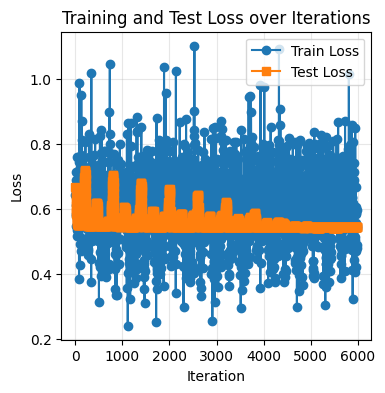

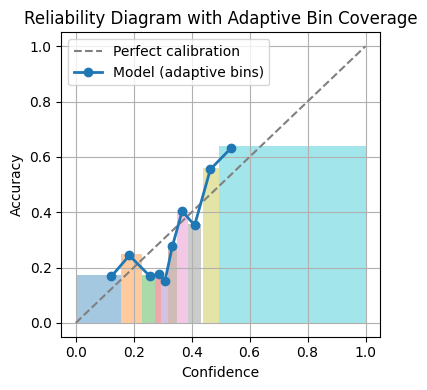

 60%|██████    | 9/15 [00:42<00:29,  4.88s/it]

Current ECE: 0.07966890931129456


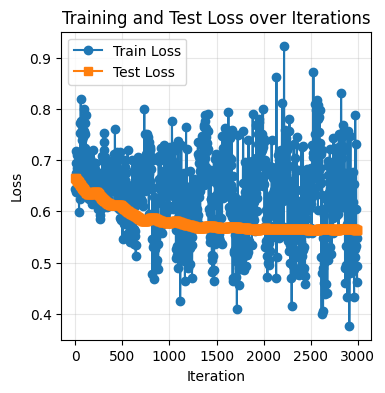

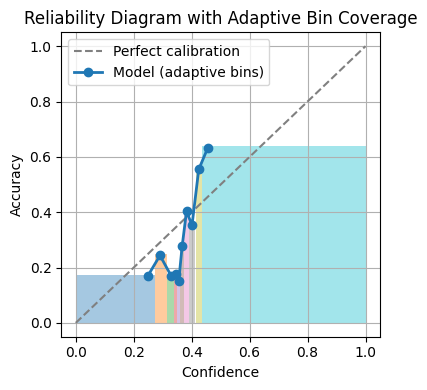

 67%|██████▋   | 10/15 [00:45<00:21,  4.38s/it]

Current ECE: 0.11330695450305939


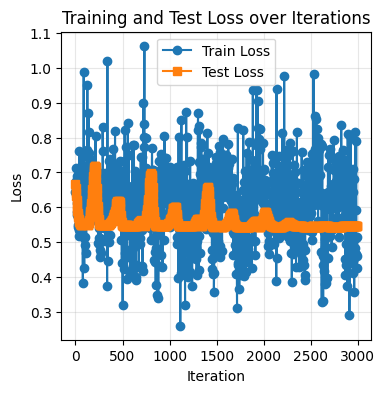

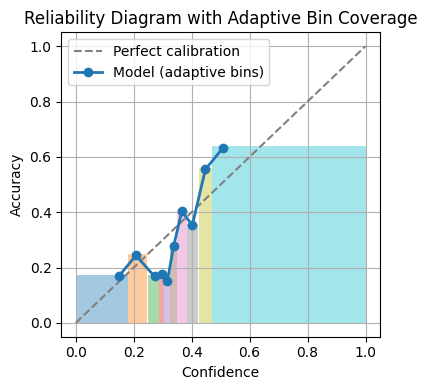

 73%|███████▎  | 11/15 [00:48<00:15,  3.85s/it]

Current ECE: 0.0828145444393158


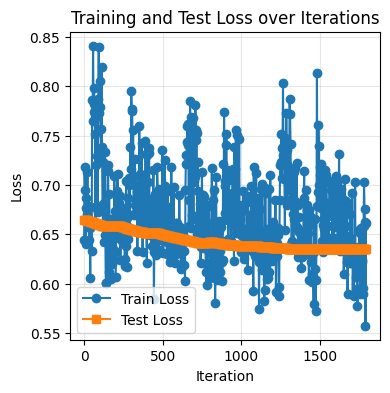

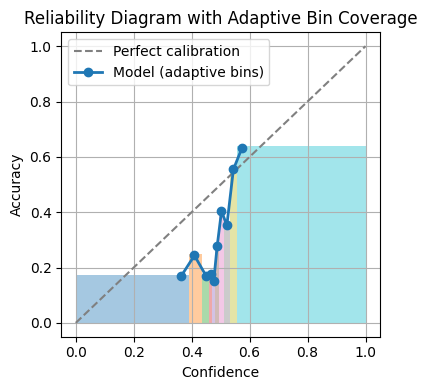

 80%|████████  | 12/15 [00:50<00:09,  3.28s/it]

Current ECE: 0.17973627150058746


 80%|████████  | 12/15 [00:54<00:13,  4.52s/it]


KeyboardInterrupt: 

In [ ]:
fit_results = fit_hparameters(
    train_data=train,
    test_data=val,
    verbose=True
)

### Testing model

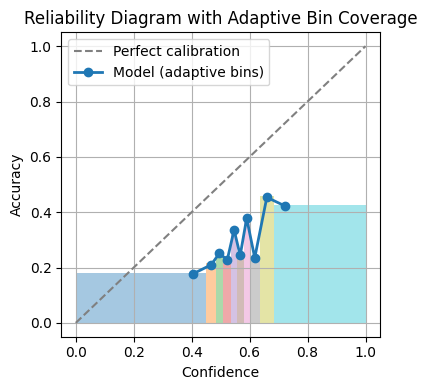

ECE on NON calibrated answer (test data): 0.26616644859313965


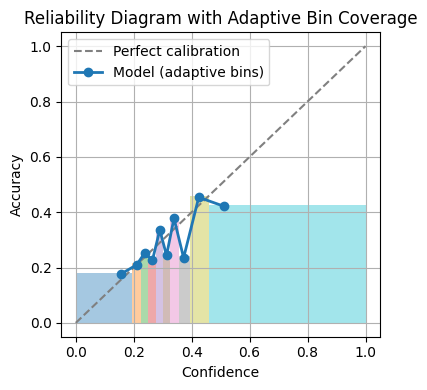

ECE on calibrated answer (test data): 0.048551298677921295
Accuracy on answer from test: 0.2944120168685913


: 

In [ ]:
model = BetaCalibration()
model.load_state_dict(fit_results["parameters"])
model.eval()
    
test_calibration_model(
    model,
    test.get()["confidence"],
    test.get()["labels"],
)